# Electricity Theft Detection

**Track:** Energy Systems — Predictive Maintenance / Anomaly Detection
**Advanced Topics:** XAI (SHAP) + Adversarial Robustness (FGSM)
**Dataset:** UCI Electricity Load Diagrams + Synthetic Theft Labels

In [1]:
import importlib.util
import os
import random
import subprocess
import sys

SEED = 42
NUM_CPUS_REQUESTED = 32
THREADS_STR = str(NUM_CPUS_REQUESTED)

WINDOW_SIZE = 24
WINDOW_STRIDE = 4
TRAIN_RATIO = 0.70
VAL_RATIO = 0.10
TEST_RATIO = 0.20
ANOMALY_RATE = 0.10
MAX_METER_SERIES = 20
MAX_WINDOWS_PER_SERIES = 6000

# Must be set before NumPy/PyTorch imports in later cells.
for env_var in [
    'OMP_NUM_THREADS',
    'MKL_NUM_THREADS',
    'OPENBLAS_NUM_THREADS',
    'NUMEXPR_NUM_THREADS',
    'VECLIB_MAXIMUM_THREADS',
    'BLIS_NUM_THREADS',
]:
    os.environ[env_var] = THREADS_STR

os.environ['OMP_DYNAMIC'] = 'FALSE'
os.environ['MKL_DYNAMIC'] = 'FALSE'
os.environ['KMP_AFFINITY'] = 'granularity=fine,compact,1,0'
os.environ['PYTHONHASHSEED'] = str(SEED)

PACKAGE_MAP = {
    'numpy': 'numpy',
    'pandas': 'pandas',
    'matplotlib': 'matplotlib',
    'seaborn': 'seaborn',
    'sklearn': 'scikit-learn',
    'torch': 'torch',
    'shap': 'shap',
    'lime': 'lime',
    'kagglehub': 'kagglehub',
}

missing = [pip_name for module_name, pip_name in PACKAGE_MAP.items() if importlib.util.find_spec(module_name) is None]

if missing:
    print(f'Installing missing packages: {missing}')
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q'] + missing)
else:
    print('All required packages already available in this kernel.')

print(f'Thread env configured to {THREADS_STR} for OpenMP/BLAS backends.')
print('Dependency check complete.')

All required packages already available in this kernel.
Thread env configured to 32 for OpenMP/BLAS backends.
Dependency check complete.


In [2]:
import os
import random
import warnings
from copy import deepcopy

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import shap
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import (
    auc,
    average_precision_score,
    balanced_accuracy_score,
    brier_score_loss,
    classification_report,
    cohen_kappa_score,
    confusion_matrix,
    f1_score,
    log_loss,
    matthews_corrcoef,
    precision_recall_curve,
    precision_recall_fscore_support,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset, WeightedRandomSampler

warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

NUM_CPUS_REQUESTED = int(os.environ.get('OMP_NUM_THREADS', '32'))
AVAILABLE_CPUS = os.cpu_count() or 1
CPU_THREADS = min(NUM_CPUS_REQUESTED, AVAILABLE_CPUS)
torch.set_num_threads(CPU_THREADS)
if hasattr(torch, 'set_num_interop_threads'):
    try:
        torch.set_num_interop_threads(CPU_THREADS)
    except RuntimeError:
        pass  # Already initialized in this kernel session.

USE_GPU = torch.cuda.is_available()
USE_AMP = USE_GPU
device = torch.device('cuda' if USE_GPU else 'cpu')

if USE_GPU:
    torch.backends.cudnn.benchmark = True
    BATCH_SIZE = 512
    EVAL_BATCH_SIZE = 1024
    NUM_WORKERS = min(8, AVAILABLE_CPUS)
else:
    torch.backends.mkldnn.enabled = True
    BATCH_SIZE = 512
    EVAL_BATCH_SIZE = 1024
    NUM_WORKERS = 0

PIN_MEMORY = USE_GPU

print(f'PyTorch: {torch.__version__}')
print(f'SHAP: {shap.__version__}')
print(f'Device: {device}')
if USE_GPU:
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'GPU memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB')
print(f'CPU threads configured: {CPU_THREADS}/{AVAILABLE_CPUS}')
print(f'torch.get_num_threads(): {torch.get_num_threads()}')
print(f'torch.get_num_interop_threads(): {torch.get_num_interop_threads()}')
print(f'Batch sizes -> train: {BATCH_SIZE}, eval: {EVAL_BATCH_SIZE}')
print(f'DataLoader workers: {NUM_WORKERS}')
print(f'Automatic mixed precision: {USE_AMP}')
print('Torch parallel info:')
print(torch.__config__.parallel_info())

PyTorch: 2.11.0+cu130
SHAP: 0.51.0
Device: cuda
GPU: NVIDIA GeForce RTX 3090
GPU memory: 23.56 GB
CPU threads configured: 32/32
torch.get_num_threads(): 32
torch.get_num_interop_threads(): 32
Batch sizes -> train: 512, eval: 1024
DataLoader workers: 8
Automatic mixed precision: True
Torch parallel info:
ATen/Parallel:
	at::get_num_threads() : 32
	at::get_num_interop_threads() : 32
OpenMP 201511 (a.k.a. OpenMP 4.5)
	omp_get_max_threads() : 32
Intel(R) oneAPI Math Kernel Library Version 2024.2-Product Build 20240605 for Intel(R) 64 architecture applications
	mkl_get_max_threads() : 32
Intel(R) MKL-DNN v3.10.2 (Git Hash f1d471933dc852f956fd05389f9313c7148783d5)
std::thread::hardware_concurrency() : 32
Environment variables:
	OMP_NUM_THREADS : 32
	MKL_NUM_THREADS : 32
ATen parallel backend: OpenMP



## Data Acquisition and Exploratory Analysis

This section downloads the dataset, keeps the highest-variance meter streams, and builds richer sliding windows for training, validation, and testing.

In [3]:
import glob
import os

import kagglehub

def read_tabular_file(file_path):
    """Read CSV/TXT with simple delimiter fallback."""
    try:
        return pd.read_csv(file_path, sep=None, engine='python')
    except Exception:
        pass
    try:
        return pd.read_csv(file_path, sep=';')
    except Exception:
        return pd.read_csv(file_path)

def collect_numeric_candidates(frame):
    candidates = []
    for col in frame.columns:
        series = pd.to_numeric(frame[col].astype(str).str.replace(',', '.', regex=False), errors='coerce')
        valid = int(series.notna().sum())
        if valid == 0:
            continue
        std = float(series.std(skipna=True))
        if np.isfinite(std):
            candidates.append((col, series.ffill().bfill().astype(np.float32), valid, std))
    return candidates

path = kagglehub.dataset_download('eduardojst10/electricityloaddiagrams20112014')
print(f'Dataset downloaded to: {path}')

meter_files = sorted(glob.glob(os.path.join(path, '**', 'Meter_*.csv'), recursive=True))
candidate_files = sorted(
    set(
        glob.glob(os.path.join(path, '**', '*.csv'), recursive=True)
        + glob.glob(os.path.join(path, '**', '*.txt'), recursive=True)
    )
 )

if not meter_files and not candidate_files:
    raise FileNotFoundError('No CSV/TXT data files found in downloaded dataset.')

series_candidates = []

if meter_files:
    print(f'Found {len(meter_files)} meter files.')
    for meter_path in meter_files:
        frame = read_tabular_file(meter_path)
        numeric_candidates = collect_numeric_candidates(frame)
        if not numeric_candidates:
            continue
        best_col, best_series, valid, std = max(numeric_candidates, key=lambda item: (item[3], item[2]))
        series_candidates.append({
            'name': f"{os.path.splitext(os.path.basename(meter_path))[0]}::{best_col}",
            'series': best_series.to_numpy(dtype=np.float32),
            'source': meter_path,
            'column': best_col,
            'valid': valid,
            'std': std,
        })
else:
    print('No per-meter files found; falling back to the widest tabular file.')
    best_file = None
    best_candidates = None
    best_score = -1
    for candidate_file in candidate_files:
        frame = read_tabular_file(candidate_file)
        numeric_candidates = collect_numeric_candidates(frame)
        score = len(numeric_candidates)
        if score > best_score:
            best_score = score
            best_file = candidate_file
            best_candidates = numeric_candidates
    if not best_candidates:
        raise ValueError('No numeric meter columns found in the tabular dataset.')
    print(f'Using wide file: {best_file}')
    for col_name, series, valid, std in sorted(best_candidates, key=lambda item: (item[3], item[2]), reverse=True):
        series_candidates.append({
            'name': col_name,
            'series': series.to_numpy(dtype=np.float32),
            'source': best_file,
            'column': col_name,
            'valid': valid,
            'std': std,
        })

if not series_candidates:
    raise ValueError('No usable meter streams were extracted from the dataset.')

series_candidates.sort(key=lambda item: (item['std'], item['valid']), reverse=True)
selected_candidates = series_candidates[:MAX_METER_SERIES]

meter_frame = pd.DataFrame({
    item['name']: pd.Series(item['series'])
    for item in selected_candidates
})
meter_frame = meter_frame.loc[:, meter_frame.std(axis=0, skipna=True).sort_values(ascending=False).index]
df = meter_frame.copy()

meter_stats = pd.DataFrame([
    {
        'meter_name': item['name'],
        'source': item['source'],
        'column': item['column'],
        'valid': item['valid'],
        'std': item['std'],
        'length': len(item['series']),
    }
    for item in selected_candidates
]).sort_values('std', ascending=False).reset_index(drop=True)

print(f'Selected {len(selected_candidates)} meter streams out of {len(series_candidates)} candidates.')
print(f'Meter frame shape (ragged rows are expected): {df.shape}')
print('Top selected meter streams by variance:')
print(meter_stats.head(10).to_string(index=False))
print(df.info())
print(df.describe().T[['mean', 'std', 'min', 'max']].head(10))

Dataset downloaded to: /home/jovyan/.cache/kagglehub/datasets/eduardojst10/electricityloaddiagrams20112014/versions/1
No per-meter files found; falling back to the widest tabular file.
Using wide file: /home/jovyan/.cache/kagglehub/datasets/eduardojst10/electricityloaddiagrams20112014/versions/1/df_kwh_adjusted.csv
Selected 20 meter streams out of 370 candidates.
Meter frame shape (ragged rows are expected): (140256, 20)
Top selected meter streams by variance:
meter_name                                                                                                             source column  valid         std  length
    MT_362 /home/jovyan/.cache/kagglehub/datasets/eduardojst10/electricityloaddiagrams20112014/versions/1/df_kwh_adjusted.csv MT_362 140256 9681.456909  140256
    MT_196 /home/jovyan/.cache/kagglehub/datasets/eduardojst10/electricityloaddiagrams20112014/versions/1/df_kwh_adjusted.csv MT_196 140256 2657.335284  140256
    MT_279 /home/jovyan/.cache/kagglehub/datasets/eduar

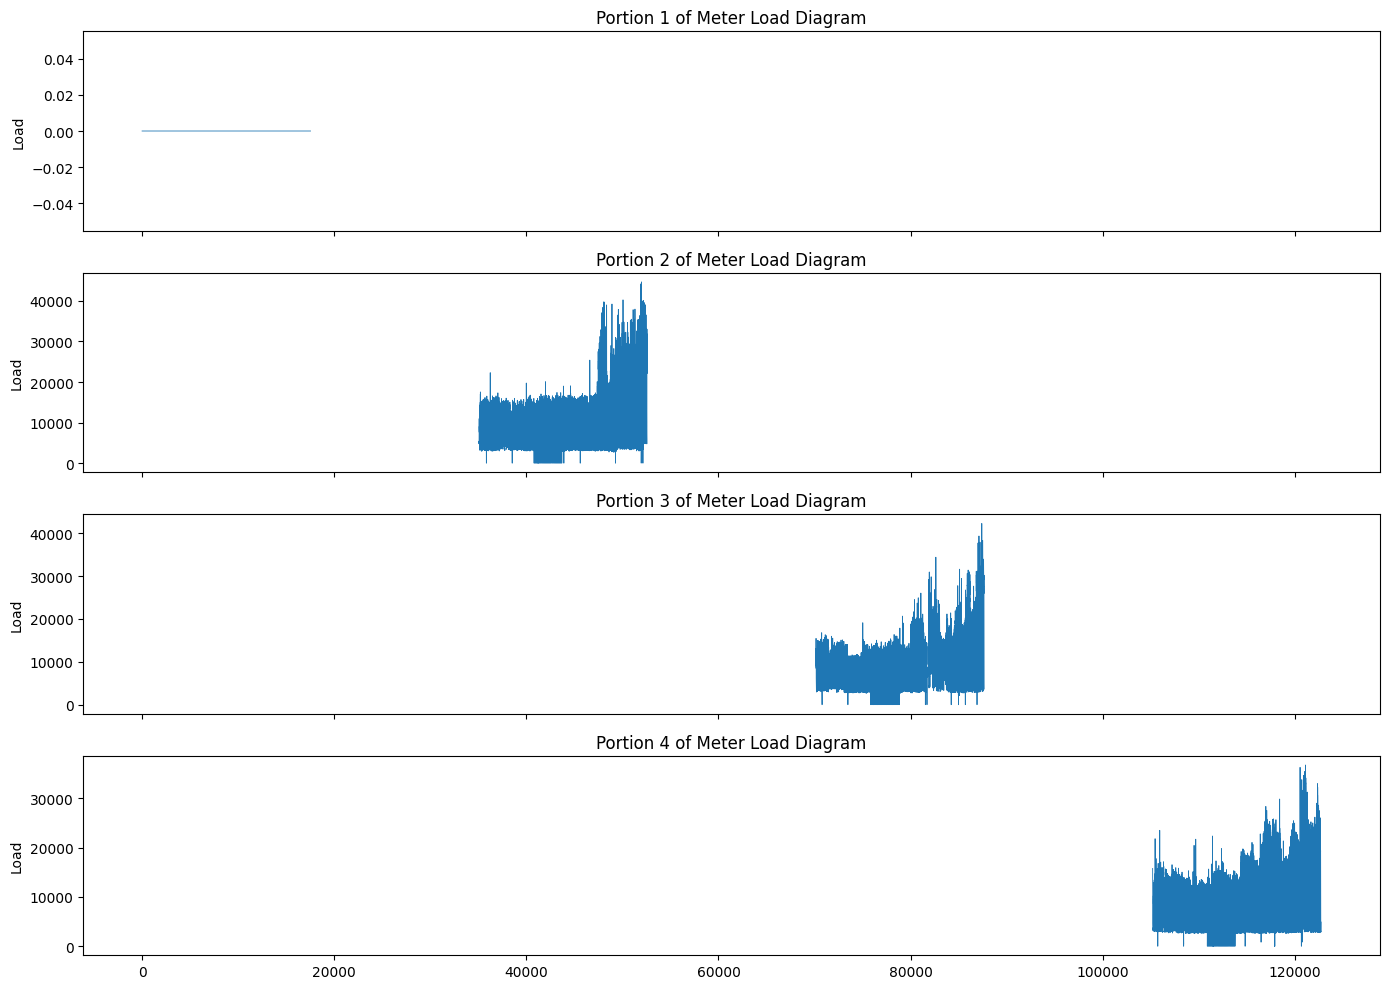

                load
count  140256.000000
mean     9390.235352
std      9681.457031
min         0.000000
25%         0.000000
50%      6025.000000
75%     13700.000000
max     48200.000000
Missing values per column:
Series([], dtype: int64)


In [4]:
# Plot the highest-variance meter streams for a quick sanity check.
top_plot_cols = meter_stats['meter_name'].head(min(4, len(meter_stats))).tolist()
fig, axes = plt.subplots(len(top_plot_cols), 1, figsize=(14, 3.5 * len(top_plot_cols)), sharex=False)

if len(top_plot_cols) == 1:
    axes = [axes]

for ax, col in zip(axes, top_plot_cols):
    series = df[col].dropna().astype(float).values
    segment_length = min(len(series), WINDOW_SIZE * 14)
    ax.plot(np.arange(segment_length), series[:segment_length], linewidth=0.7)
    ax.set_title(f'High-variance meter stream: {col}')
    ax.set_ylabel('Load')
    ax.grid(alpha=0.2)

axes[-1].set_xlabel('Time index')
plt.tight_layout()
plt.savefig('baseline_load_patterns.png', dpi=150, bbox_inches='tight')
plt.show()

print(df.describe().T[['mean', 'std', 'min', 'max']])

missing = df.isnull().sum()
missing = missing[missing > 0]
if len(missing) > 0:
    print(f'Missing values per column:\n{missing}')
else:
    print('No missing values after loading and alignment.')

In [5]:
def create_time_windows(data, window_size=WINDOW_SIZE, stride=WINDOW_STRIDE, max_windows=MAX_WINDOWS_PER_SERIES):
    """Build sliding windows from a 1D meter series."""
    data = np.asarray(data, dtype=np.float32)
    if len(data) < window_size:
        return np.empty((0, window_size), dtype=np.float32), np.empty((0,), dtype=np.int64)

    starts = np.arange(0, len(data) - window_size + 1, stride, dtype=np.int64)
    if len(starts) > max_windows:
        starts = np.linspace(0, len(data) - window_size, max_windows, dtype=np.float32).astype(np.int64)

    windows = np.stack([data[start:start + window_size] for start in starts], axis=0)
    return windows.astype(np.float32), starts.astype(np.int64)

def inject_theft(window, rng):
    """Apply one of five realistic synthetic theft patterns to a window."""
    window = np.asarray(window, dtype=np.float32).copy()
    theft_type = int(rng.integers(0, 5))

    if theft_type == 0:
        scale = float(rng.uniform(0.25, 0.75))
        return (window * scale).astype(np.float32)

    if theft_type == 1:
        spike_profile = rng.uniform(0.25, 1.0, size=window.shape).astype(np.float32)
        spike_strength = float(rng.uniform(1.5, 3.0)) * max(float(np.mean(np.abs(window))), 1e-3)
        return (window + spike_profile * spike_strength).astype(np.float32)

    if theft_type == 2:
        constant = float(rng.uniform(0.0, max(float(window.max()) * 0.05, 1e-3)))
        return np.full_like(window, constant, dtype=np.float32)

    if theft_type == 3:
        mask = rng.choice([0.0, 1.0], size=window.shape, p=[0.45, 0.55]).astype(np.float32)
        return (window * mask).astype(np.float32)

    shift = int(rng.integers(3, min(8, len(window))))
    shifted = np.roll(window, shift).astype(np.float32)
    shifted[:shift] = shifted[shift]
    return shifted

def generate_synthetic_labels(load_windows, n_anomalies=ANOMALY_RATE, seed=SEED, noise_fraction=0.015):
    """Inject synthetic theft labels and light sensor noise into clean windows."""
    rng = np.random.default_rng(seed)
    corrupted_windows = np.asarray(load_windows, dtype=np.float32).copy()
    window_scales = np.maximum(
        corrupted_windows.std(axis=1, keepdims=True),
        np.maximum(np.abs(corrupted_windows).mean(axis=1, keepdims=True), 1.0),
    )
    noise = rng.normal(0.0, noise_fraction, size=corrupted_windows.shape).astype(np.float32) * window_scales.astype(np.float32)
    corrupted_windows = corrupted_windows + noise

    labels = np.zeros(len(corrupted_windows), dtype=np.int64)
    n_anom = max(1, int(round(len(corrupted_windows) * n_anomalies)))
    anomaly_indices = rng.choice(len(corrupted_windows), size=n_anom, replace=False)

    for idx in anomaly_indices:
        corrupted_windows[idx] = inject_theft(corrupted_windows[idx], rng)
        labels[idx] = 1

    return corrupted_windows.astype(np.float32), labels

def build_window_features(load_windows, window_size=WINDOW_SIZE):
    """Expand each load window into richer temporal and statistical features."""
    load_windows = np.asarray(load_windows, dtype=np.float32)
    if load_windows.ndim != 2:
        raise ValueError('load_windows must have shape (n_samples, window_size).')

    steps = np.arange(window_size, dtype=np.float32)
    hour_angle = 2.0 * np.pi * (steps % 24.0) / 24.0
    hour_sin = np.broadcast_to(np.sin(hour_angle).astype(np.float32), load_windows.shape)
    hour_cos = np.broadcast_to(np.cos(hour_angle).astype(np.float32), load_windows.shape)

    win_mean = np.repeat(load_windows.mean(axis=1, keepdims=True), window_size, axis=1)
    win_std = np.repeat(load_windows.std(axis=1, keepdims=True), window_size, axis=1)
    win_max = np.repeat(load_windows.max(axis=1, keepdims=True), window_size, axis=1)
    win_min = np.repeat(load_windows.min(axis=1, keepdims=True), window_size, axis=1)
    load_ratio = load_windows / (win_mean + 1e-8)
    flatness = win_std / (np.abs(win_mean) + 1e-8)
    flatness = np.clip(flatness, 0.0, 10.0)

    diffs = np.diff(load_windows, axis=1, prepend=load_windows[:, :1])
    abs_diffs = np.abs(diffs)
    mean_abs_diff = np.repeat(abs_diffs.mean(axis=1, keepdims=True), window_size, axis=1)
    diff_std = np.repeat(abs_diffs.std(axis=1, keepdims=True), window_size, axis=1)
    zero_fraction = np.repeat((np.abs(load_windows) <= 1e-3).mean(axis=1, keepdims=True), window_size, axis=1)

    centered_steps = steps - steps.mean()
    slope = (
        ((load_windows - load_windows.mean(axis=1, keepdims=True)) * centered_steps).sum(axis=1, keepdims=True)
        / (np.sum(centered_steps ** 2) + 1e-8)
    )
    slope = np.repeat(slope, window_size, axis=1)

    range_ratio = (win_max - win_min) / (np.abs(win_mean) + 1e-8)

    features = np.stack(
        [
            load_windows,
            hour_sin,
            hour_cos,
            win_mean,
            win_std,
            win_max,
            win_min,
            load_ratio,
            flatness,
            mean_abs_diff,
            diff_std,
            zero_fraction,
            slope,
            range_ratio,
        ],
        axis=-1,
    )

    return features.astype(np.float32)

FEATURE_NAMES = [
    'load',
    'hour_sin',
    'hour_cos',
    'win_mean',
    'win_std',
    'win_max',
    'win_min',
    'load_ratio',
    'flatness',
    'mean_abs_diff',
    'diff_std',
    'zero_fraction',
    'slope',
    'range_ratio',
]
FEATURE_DIM = len(FEATURE_NAMES)
print(f'Feature set: {FEATURE_NAMES}')
print(f'Feature dimension: {FEATURE_DIM}')

Feature set: ['load', 'hour_sin', 'hour_cos', 'win_mean', 'win_std', 'win_max', 'win_min', 'load_ratio', 'flatness', 'mean_abs_diff', 'diff_std', 'zero_fraction', 'slope', 'range_ratio']
Feature dimension: 14


In [6]:
def generate_synthetic_labels(X_load, n_anomalies=0.15, seed=42):
    """
    Generate synthetic electricity theft labels by injecting anomalies into normal load data.
    Three types of theft patterns:
    - Sudden drops (bypassed meter): reduce consumption 50-80%
    - Unusual spikes (illegal connections): add 2-3x normal baseline
    - Flat-line periods (tampered reading): set to zero or constant

    Returns corrupted load array and binary labels.
    """
    np.random.seed(seed)
    n_samples = len(X_load)
    labels = np.zeros(n_samples, dtype=int)
    X_corrupted = X_load.copy()

    n_anom = int(n_samples * n_anomalies)
    anom_indices = np.random.choice(n_samples, n_anom, replace=False)

    anomaly_types = np.random.randint(0, 3, n_anom)

    for idx, atype in zip(anom_indices, anomaly_types):
        if atype == 0:  # Sudden drop (bypassed meter)
            reduction = np.random.uniform(0.5, 0.8)
            X_corrupted[idx] *= reduction
            labels[idx] = 1
        elif atype == 1:  # Unusual spike (illegal connection)
            multiplier = np.random.uniform(2.0, 3.0)
            baseline_mean = X_load[idx].mean()
            X_corrupted[idx] += baseline_mean * (multiplier - 1)
            labels[idx] = 1
        else:  # Flat-line (tampered reading)
            constant_val = np.random.uniform(0, X_load[idx].max() * 0.1)
            X_corrupted[idx] = constant_val
            labels[idx] = 1

    return X_corrupted, labels

X_thief, y_labels = generate_synthetic_labels(X_load, n_anomalies=0.15)
print(f'Anomaly rate: {y_labels.mean():.2%}')

Anomaly rate: 15.00%


In [7]:
# Build a pooled dataset from multiple meter streams, then stratify the full window pool.
selected_meter_names = meter_stats['meter_name'].tolist()

all_feature_blocks = []
all_label_blocks = []

for meter_idx, meter_name in enumerate(selected_meter_names):
    series = df[meter_name].dropna().astype(np.float32).to_numpy()
    meter_windows, meter_offsets = create_time_windows(
        series,
        window_size=WINDOW_SIZE,
        stride=WINDOW_STRIDE,
        max_windows=MAX_WINDOWS_PER_SERIES,
    )
    if len(meter_windows) < 10:
        print(f'Skipping {meter_name} because it is too short after windowing ({len(meter_windows)} windows).')
        continue

    meter_windows, meter_labels = generate_synthetic_labels(
        meter_windows,
        n_anomalies=ANOMALY_RATE,
        seed=SEED + meter_idx,
        noise_fraction=0.015,
    )
    meter_features = build_window_features(meter_windows, window_size=WINDOW_SIZE)
    all_feature_blocks.append(meter_features)
    all_label_blocks.append(meter_labels)

    print(
        f'{meter_name}: windows={len(meter_features)}, '
        f'anomaly_rate={meter_labels.mean():.2%}'
    )

if not all_feature_blocks:
    raise RuntimeError('Failed to build any windows from the available meter streams.')

X_all_raw = np.concatenate(all_feature_blocks, axis=0)
y_all = np.concatenate(all_label_blocks, axis=0)

X_temp_raw, X_test_raw, y_temp, y_test = train_test_split(
    X_all_raw,
    y_all,
    test_size=TEST_RATIO,
    random_state=SEED,
    stratify=y_all,
 )

val_fraction = VAL_RATIO / (TRAIN_RATIO + VAL_RATIO)
X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    X_temp_raw,
    y_temp,
    test_size=val_fraction,
    random_state=SEED,
    stratify=y_temp,
 )

feature_mean = X_train_raw.mean(axis=(0, 1), keepdims=True)
feature_std = X_train_raw.std(axis=(0, 1), keepdims=True) + 1e-8
X_train = (X_train_raw - feature_mean) / feature_std
X_val = (X_val_raw - feature_mean) / feature_std
X_test = (X_test_raw - feature_mean) / feature_std

X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)
X_val_t = torch.tensor(X_val, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.long)
X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.long)

train_dataset = TensorDataset(X_train_t, y_train_t)
val_dataset = TensorDataset(X_val_t, y_val_t)
test_dataset = TensorDataset(X_test_t, y_test_t)

class_counts = np.bincount(y_train, minlength=2)
class_weights = 1.0 / np.maximum(class_counts, 1)
sample_weights = class_weights[y_train]
train_sampler = WeightedRandomSampler(
    weights=torch.tensor(sample_weights, dtype=torch.double),
    num_samples=len(sample_weights),
    replacement=True,
 )

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    sampler=train_sampler,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=NUM_WORKERS > 0,
 )
val_loader = DataLoader(
    val_dataset,
    batch_size=EVAL_BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=NUM_WORKERS > 0,
 )
test_loader = DataLoader(
    test_dataset,
    batch_size=EVAL_BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=NUM_WORKERS > 0,
 )

print(f'Class counts in training set: normal={class_counts[0]}, theft={class_counts[1]}')
print(f'Sampling weights: normal={class_weights[0]:.6f}, theft={class_weights[1]:.6f}')
print(f'X_train shape: {X_train_t.shape}')
print(f'X_val shape:   {X_val_t.shape}')
print(f'X_test shape:  {X_test_t.shape}')
print(f'Train anomalies: {y_train.sum()} / {len(y_train)}')
print(f'Val anomalies:   {y_val.sum()} / {len(y_val)}')
print(f'Test anomalies:  {y_test.sum()} / {len(y_test)}')
print(f'Train anomaly rate: {y_train.mean():.2%}')
print(f'Val anomaly rate:   {y_val.mean():.2%}')
print(f'Test anomaly rate:  {y_test.mean():.2%}')

MT_362: windows=6000, anomaly_rate=10.00%
MT_196: windows=6000, anomaly_rate=10.00%
MT_279: windows=6000, anomaly_rate=10.00%
MT_370: windows=6000, anomaly_rate=10.00%
MT_228: windows=6000, anomaly_rate=10.00%
MT_364: windows=6000, anomaly_rate=10.00%
MT_208: windows=6000, anomaly_rate=10.00%
MT_351: windows=6000, anomaly_rate=10.00%
MT_222: windows=6000, anomaly_rate=10.00%
MT_147: windows=6000, anomaly_rate=10.00%
MT_194: windows=6000, anomaly_rate=10.00%
MT_220: windows=6000, anomaly_rate=10.00%
MT_357: windows=6000, anomaly_rate=10.00%
MT_241: windows=6000, anomaly_rate=10.00%
MT_339: windows=6000, anomaly_rate=10.00%
MT_043: windows=6000, anomaly_rate=10.00%
MT_223: windows=6000, anomaly_rate=10.00%
MT_323: windows=6000, anomaly_rate=10.00%
MT_328: windows=6000, anomaly_rate=10.00%
MT_224: windows=6000, anomaly_rate=10.00%
Class counts in training set: normal=75599, theft=8400
Sampling weights: normal=0.000013, theft=0.000119
X_train shape: torch.Size([83999, 24, 14])
X_val shape:

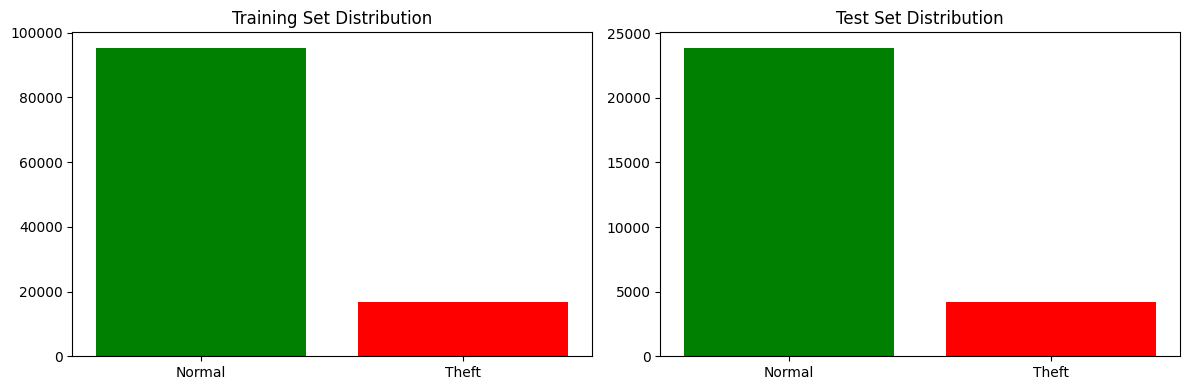

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

train_normal = int((y_train == 0).sum())
train_theft = int((y_train == 1).sum())
val_normal = int((y_val == 0).sum())
val_theft = int((y_val == 1).sum())
test_normal = int((y_test == 0).sum())
test_theft = int((y_test == 1).sum())

axes[0].bar(['Normal', 'Theft'], [train_normal, train_theft], color=['green', 'red'])
axes[0].set_title('Training Set')

axes[1].bar(['Normal', 'Theft'], [val_normal, val_theft], color=['green', 'red'])
axes[1].set_title('Validation Set')

axes[2].bar(['Normal', 'Theft'], [test_normal, test_theft], color=['green', 'red'])
axes[2].set_title('Test Set')

for ax in axes:
    ax.set_ylabel('Count')
    ax.grid(axis='y', alpha=0.2)

plt.tight_layout()
plt.savefig('label_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
class TheftDetectionLSTM(nn.Module):
    def __init__(self, input_size=FEATURE_DIM, conv_channels=64, hidden_size=128, num_layers=2, dropout=0.3):
        super().__init__()
        self.feature_extractor = nn.Sequential(
            nn.Conv1d(input_size, conv_channels, kernel_size=3, padding=1),
            nn.BatchNorm1d(conv_channels),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Conv1d(conv_channels, conv_channels, kernel_size=3, padding=1),
            nn.BatchNorm1d(conv_channels),
            nn.GELU(),
        )
        self.lstm = nn.LSTM(
            input_size=conv_channels,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.classifier = nn.Sequential(
            nn.LayerNorm(hidden_size * 2),
            nn.Linear(hidden_size * 2, 64),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1),
        )

    def forward(self, x):
        x = x.permute(0, 2, 1)
        x = self.feature_extractor(x)
        x = x.permute(0, 2, 1)
        _, (h_n, _) = self.lstm(x)
        latent = torch.cat([h_n[-2], h_n[-1]], dim=-1)
        logits = self.classifier(latent)
        return logits.squeeze(-1)

model = TheftDetectionLSTM(
    input_size=FEATURE_DIM,
    conv_channels=64,
    hidden_size=128,
    num_layers=2,
    dropout=0.3,
 ).to(device)
print(model)
print(f'Total parameters: {sum(p.numel() for p in model.parameters())}')

TheftDetectionLSTM(
  (feature_extractor): Sequential(
    (0): Conv1d(14, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): GELU(approximate='none')
    (3): Dropout(p=0.3, inplace=False)
    (4): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): GELU(approximate='none')
  )
  (lstm): LSTM(64, 128, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (classifier): Sequential(
    (0): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
    (1): Linear(in_features=256, out_features=64, bias=True)
    (2): GELU(approximate='none')
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=64, out_features=1, bias=True)
  )
)
Total parameters: 626305


Epoch [01/100] train_loss=0.0477 val_loss=0.0435 val_ap=0.6947 val_f1=0.6848 val_precision=0.9211 val_recall=0.5450 threshold=0.69
Epoch [02/100] train_loss=0.0448 val_loss=0.0462 val_ap=0.7193 val_f1=0.7125 val_precision=0.9150 val_recall=0.5833 threshold=0.69
Epoch [03/100] train_loss=0.0443 val_loss=0.0453 val_ap=0.7172 val_f1=0.7008 val_precision=0.8558 val_recall=0.5933 threshold=0.67
Epoch [04/100] train_loss=0.0432 val_loss=0.0445 val_ap=0.7446 val_f1=0.7398 val_precision=0.9283 val_recall=0.6150 threshold=0.76
Epoch [05/100] train_loss=0.0430 val_loss=0.0419 val_ap=0.7054 val_f1=0.6907 val_precision=0.8627 val_recall=0.5758 threshold=0.63
Epoch [06/100] train_loss=0.0423 val_loss=0.0415 val_ap=0.7513 val_f1=0.7479 val_precision=0.9384 val_recall=0.6217 threshold=0.69
Epoch [07/100] train_loss=0.0421 val_loss=0.0407 val_ap=0.7235 val_f1=0.7171 val_precision=0.8911 val_recall=0.6000 threshold=0.64
Epoch [08/100] train_loss=0.0420 val_loss=0.0439 val_ap=0.7233 val_f1=0.7258 val_pr

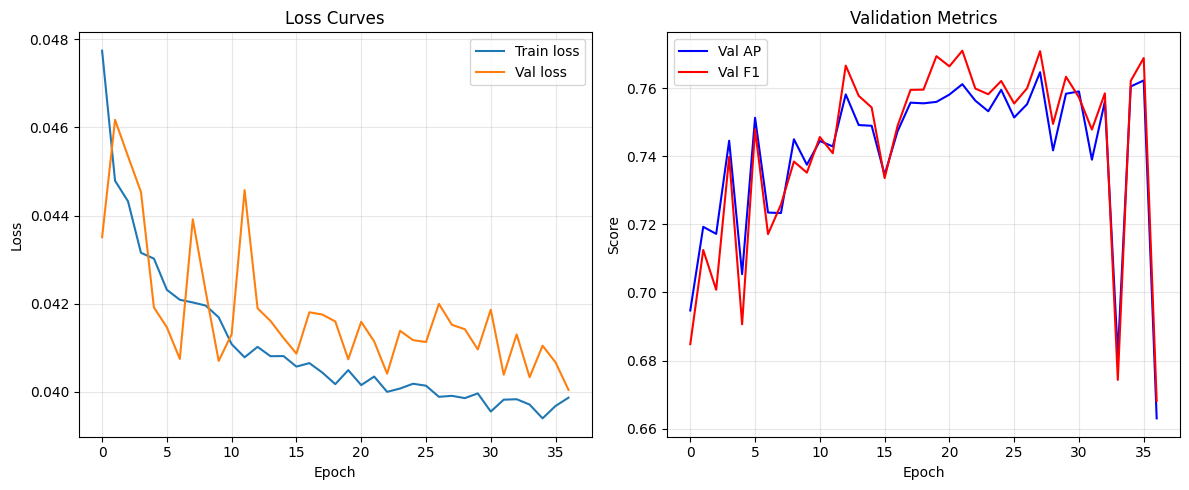

Best validation F1: 0.7710 at threshold 0.75
Best validation AP: 0.7612
Model saved to theft_detection_lstm.pth after 37 epochs.


In [10]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.8, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, logits, targets):
        targets = targets.float()
        bce = F.binary_cross_entropy_with_logits(logits, targets, reduction='none')
        probs = torch.sigmoid(logits)
        pt = torch.where(targets == 1.0, probs, 1.0 - probs)
        alpha_t = torch.where(targets == 1.0, torch.full_like(targets, self.alpha), torch.full_like(targets, 1.0 - self.alpha))
        loss = alpha_t * torch.pow(1.0 - pt, self.gamma) * bce
        return loss.mean()

criterion = FocalLoss(alpha=0.8, gamma=2.0)
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='max',
    factor=0.5,
    patience=3,
    min_lr=1e-5,
 )
scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)
autocast_device = 'cuda' if USE_GPU else 'cpu'

epochs = 100
patience = 15
min_delta = 1e-4
threshold_grid = np.linspace(0.05, 0.95, 91)

best_clean_state = None
best_val_f1 = -np.inf
best_val_ap = -np.inf
best_threshold = 0.5
best_threshold_metrics = {}
best_curve_idx = -1

clean_train_losses = []
clean_val_losses = []
clean_val_aps = []
clean_val_f1s = []
clean_metrics = {}
clean_patience_counter = 0

def collect_probabilities(loader):
    model.eval()
    logits_list = []
    probs_list = []
    targets_list = []
    total_loss = 0.0
    total_count = 0

    with torch.no_grad():
        for batch_X, batch_y in loader:
            batch_X = batch_X.to(device, non_blocking=PIN_MEMORY)
            batch_y_float = batch_y.float().to(device, non_blocking=PIN_MEMORY)

            with torch.autocast(device_type=autocast_device, dtype=torch.float16, enabled=USE_AMP):
                logits = model(batch_X)
                loss = criterion(logits, batch_y_float)

            probs = torch.sigmoid(logits)
            logits_list.append(logits.detach().float().cpu().numpy())
            probs_list.append(probs.detach().float().cpu().numpy())
            targets_list.append(batch_y.detach().cpu().numpy())
            total_loss += loss.item() * len(batch_y)
            total_count += len(batch_y)

    return (
        np.concatenate(logits_list) if logits_list else np.empty((0,), dtype=np.float32),
        np.concatenate(probs_list) if probs_list else np.empty((0,), dtype=np.float32),
        np.concatenate(targets_list) if targets_list else np.empty((0,), dtype=np.int64),
        total_loss / max(total_count, 1),
    )

def optimize_threshold(y_true_array, prob_array, thresholds=threshold_grid):
    best_tuple = (-np.inf, -np.inf, -np.inf)
    best_threshold_local = 0.5
    best_metrics_local = {}
    threshold_rows = []

    for threshold_value in thresholds:
        predictions = (prob_array >= threshold_value).astype(np.int64)
        precision_value = precision_score(y_true_array, predictions, zero_division=0)
        recall_value = recall_score(y_true_array, predictions, zero_division=0)
        f1_value = f1_score(y_true_array, predictions, zero_division=0)
        balanced_value = balanced_accuracy_score(y_true_array, predictions)
        mcc_value = matthews_corrcoef(y_true_array, predictions)
        threshold_rows.append([threshold_value, precision_value, recall_value, f1_value, balanced_value, mcc_value])

        current_tuple = (f1_value, precision_value, recall_value)
        if current_tuple > best_tuple:
            best_tuple = current_tuple
            best_threshold_local = float(threshold_value)
            best_metrics_local = {
                'threshold': float(threshold_value),
                'precision': float(precision_value),
                'recall': float(recall_value),
                'f1': float(f1_value),
                'balanced_accuracy': float(balanced_value),
                'mcc': float(mcc_value),
            }

    return best_threshold_local, best_metrics_local, np.asarray(threshold_rows, dtype=np.float32)

for epoch in range(epochs):
    model.train()
    epoch_loss = 0.0
    n_batches = 0

    for batch_X, batch_y in train_loader:
        batch_X = batch_X.to(device, non_blocking=PIN_MEMORY)
        batch_y = batch_y.float().to(device, non_blocking=PIN_MEMORY)

        optimizer.zero_grad(set_to_none=True)
        with torch.autocast(device_type=autocast_device, dtype=torch.float16, enabled=USE_AMP):
            logits = model(batch_X)
            loss = criterion(logits, batch_y)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()

        epoch_loss += loss.item()
        n_batches += 1

    train_loss = epoch_loss / max(n_batches, 1)
    val_logits, val_probs, val_targets, val_loss = collect_probabilities(val_loader)
    val_threshold, val_metrics, threshold_rows = optimize_threshold(val_targets, val_probs)

    try:
        val_ap = average_precision_score(val_targets, val_probs)
    except ValueError:
        val_ap = 0.0

    scheduler.step(val_metrics['f1'])

    clean_train_losses.append(train_loss)
    clean_val_losses.append(val_loss)
    clean_val_aps.append(val_ap)
    clean_val_f1s.append(val_metrics['f1'])

    clean_metrics = {
        'loss': float(val_loss),
        'ap': float(val_ap),
        'threshold': float(val_threshold),
        'precision': float(val_metrics['precision']),
        'recall': float(val_metrics['recall']),
        'f1': float(val_metrics['f1']),
        'balanced_accuracy': float(val_metrics['balanced_accuracy']),
        'mcc': float(val_metrics['mcc']),
    }

    print(
        f"Epoch [{epoch + 1:02d}/{epochs}] "
        f"train_loss={train_loss:.4f} val_loss={val_loss:.4f} "
        f"val_ap={val_ap:.4f} val_f1={val_metrics['f1']:.4f} "
        f"val_precision={val_metrics['precision']:.4f} val_recall={val_metrics['recall']:.4f} "
        f"threshold={val_threshold:.2f}"
    )

    if val_metrics['f1'] > best_val_f1 + min_delta:
        best_val_f1 = val_metrics['f1']
        best_val_ap = val_ap
        best_threshold = val_threshold
        best_threshold_metrics = val_metrics.copy()
        best_curve_idx = epoch + 1
        best_clean_state = deepcopy(model.state_dict())
        clean_patience_counter = 0
        torch.save(best_clean_state, 'theft_detection_lstm.pth')
    else:
        clean_patience_counter += 1
        if clean_patience_counter >= patience:
            print(f'Early stopping at epoch {epoch + 1} (best validation F1: {best_val_f1:.4f})')
            break

clean_epochs = len(clean_train_losses)
if best_clean_state is None:
    best_clean_state = deepcopy(model.state_dict())
    best_threshold_metrics = clean_metrics.copy()

model.load_state_dict(best_clean_state)
best_f1 = best_val_f1
threshold = best_threshold

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(clean_train_losses, label='Train loss')
plt.plot(clean_val_losses, label='Val loss')
plt.title('Loss Curves')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(alpha=0.3)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(clean_val_aps, label='Val AP', color='blue')
plt.plot(clean_val_f1s, label='Val F1', color='red')
plt.title('Validation Metrics')
plt.xlabel('Epoch')
plt.ylabel('Score')
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.savefig('training_loss.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Best validation F1: {best_val_f1:.4f} at threshold {best_threshold:.2f}')
print(f'Best validation AP: {best_val_ap:.4f}')
print(f'Model saved to theft_detection_lstm.pth after {clean_epochs} epochs.')

In [11]:
# Evaluate on the held-out test set using the validation-selected threshold.
model.load_state_dict(best_clean_state)
model.eval()

all_logits, all_probs, y_true, test_loss = collect_probabilities(test_loader)
all_preds = (all_probs >= best_threshold).astype(np.int64)

precision, recall, f1, _ = precision_recall_fscore_support(y_true, all_preds, average='binary', zero_division=0)
balanced_acc = balanced_accuracy_score(y_true, all_preds)
mcc = matthews_corrcoef(y_true, all_preds)
cohen_kappa = cohen_kappa_score(y_true, all_preds)
cm = confusion_matrix(y_true, all_preds)
test_classification_report = classification_report(y_true, all_preds, target_names=['Normal', 'Theft'], zero_division=0)

precisions_curve, recalls_curve, _ = precision_recall_curve(y_true, all_probs)
pr_auc = auc(recalls_curve, precisions_curve)
roc_auc = roc_auc_score(y_true, all_probs)
brier = brier_score_loss(y_true, all_probs)
logloss = log_loss(y_true, np.clip(all_probs, 1e-6, 1 - 1e-6))

test_metrics = {
    'precision': float(precision),
    'recall': float(recall),
    'f1': float(f1),
    'balanced_accuracy': float(balanced_acc),
    'mcc': float(mcc),
    'cohen_kappa': float(cohen_kappa),
    'test_loss': float(test_loss),
    'threshold': float(best_threshold),
    'brier': float(brier),
    'logloss': float(logloss),
    'pr_auc': float(pr_auc),
    'roc_auc': float(roc_auc),
}

clean_metrics = test_metrics.copy()

print(f'Validation-selected threshold: {best_threshold:.2f}')
print(f'Best validation metrics: {best_threshold_metrics}')
print(f'Test Precision: {precision:.4f}')
print(f'Test Recall:    {recall:.4f}')
print(f'Test F1-Score:  {f1:.4f}')
print(f'Test Balanced Accuracy: {balanced_acc:.4f}')
print(f'Test MCC: {mcc:.4f}')
print(f'Test Cohen Kappa: {cohen_kappa:.4f}')
print(f'Test PR-AUC: {pr_auc:.4f}')
print(f'Test ROC-AUC: {roc_auc:.4f}')
print(f'Test Brier Score: {brier:.4f}')
print(f'Test Log Loss: {logloss:.4f}')
print(f'\nClassification Report:\n{test_classification_report}')

Validation-selected threshold: 0.75
Best validation metrics: {'threshold': 0.7499999999999999, 'precision': 0.9544895448954489, 'recall': 0.6466666666666666, 'f1': 0.7709885742672627, 'balanced_accuracy': 0.8216205289633676, 'mcc': 0.7678473008273503}
Test Precision: 0.9422
Test Recall:    0.6112
Test F1-Score:  0.7415
Test Balanced Accuracy: 0.8035
Test MCC: 0.7394
Test Cohen Kappa: 0.7194
Test PR-AUC: 0.7443
Test ROC-AUC: 0.8718
Test Brier Score: 0.2476
Test Log Loss: 0.6786

Classification Report:
              precision    recall  f1-score   support

      Normal       0.96      1.00      0.98     21600
       Theft       0.94      0.61      0.74      2400

    accuracy                           0.96     24000
   macro avg       0.95      0.80      0.86     24000
weighted avg       0.96      0.96      0.95     24000



## Explainability Analysis (SHAP)

After baseline evaluation, this section inspects which time steps and cyclical features influence model decisions.

In [13]:
# Explain model predictions with SHAP (GradientExplainer for PyTorch sequence model).
model.eval()

class SHAPWrapper(nn.Module):
    def __init__(self, base_model):
        super().__init__()
        self.base_model = base_model

    def forward(self, x):
        return self.base_model(x).unsqueeze(-1)

def balanced_sample_indices(labels, total_size, seed=SEED):
    rng = np.random.default_rng(seed)
    labels = np.asarray(labels)
    positive_idx = np.where(labels == 1)[0]
    negative_idx = np.where(labels == 0)[0]

    selected = []
    take_positive = min(len(positive_idx), total_size // 2)
    take_negative = min(len(negative_idx), total_size - take_positive)

    if take_negative > 0:
        selected.extend(rng.choice(negative_idx, size=take_negative, replace=False).tolist())
    if take_positive > 0:
        selected.extend(rng.choice(positive_idx, size=take_positive, replace=False).tolist())

    if len(selected) < total_size:
        remaining = np.setdiff1d(np.arange(len(labels)), np.array(selected, dtype=int), assume_unique=False)
        if len(remaining) > 0:
            fill = min(total_size - len(selected), len(remaining))
            selected.extend(rng.choice(remaining, size=fill, replace=False).tolist())

    return np.array(sorted(set(selected)), dtype=np.int64)

# Run SHAP on CPU to avoid cuDNN RNN backward limitations on GPU.
shap_device = torch.device('cpu')
model_for_shap = TheftDetectionLSTM(
    input_size=FEATURE_DIM,
    conv_channels=64,
    hidden_size=128,
    num_layers=2,
    dropout=0.3,
 ).to(shap_device)
model_for_shap.load_state_dict(model.state_dict())
model_for_shap.eval()
shap_model = SHAPWrapper(model_for_shap).to(shap_device)
shap_model.eval()

# Keep the SHAP budget large enough to be meaningful but still runnable.
background_size = min(200, len(X_train_t))
test_size = min(200, len(X_test_t))
shap_nsamples = 100

background_indices = balanced_sample_indices(y_train, background_size, seed=SEED)
test_indices = balanced_sample_indices(y_true, test_size, seed=SEED + 1)

background = X_train_t[background_indices].to(shap_device)
test_samples = X_test_t[test_indices].to(shap_device)
subset_true = y_true[test_indices]
subset_preds = all_preds[test_indices]
subset_probs = all_probs[test_indices]

explainer = shap.GradientExplainer(shap_model, background)
raw_shap_values = explainer.shap_values(test_samples, nsamples=shap_nsamples)

if isinstance(raw_shap_values, list):
    shap_values = raw_shap_values[0]
else:
    shap_values = raw_shap_values

if isinstance(shap_values, torch.Tensor):
    shap_values = shap_values.detach().cpu().numpy()

shap_values = np.asarray(shap_values)
if shap_values.ndim == 4 and shap_values.shape[-1] == 1:
    shap_values = shap_values[..., 0]

test_np = test_samples.detach().cpu().numpy()
shap_flat = shap_values.reshape(shap_values.shape[0], -1)
test_flat = test_np.reshape(test_np.shape[0], -1)

feature_names = []
for step in range(WINDOW_SIZE):
    time_label = WINDOW_SIZE - 1 - step
    for feature_name in FEATURE_NAMES:
        feature_names.append(f'{feature_name}_t-{time_label}')

mean_abs_shap = np.mean(np.abs(shap_flat), axis=0)
sorted_idx = np.argsort(mean_abs_shap)[::-1]

feature_group_importance = {}
for feature_idx, feature_name in enumerate(FEATURE_NAMES):
    feature_group_importance[feature_name] = float(np.mean(np.abs(shap_flat[:, feature_idx::FEATURE_DIM])))
sorted_groups = sorted(feature_group_importance.items(), key=lambda item: item[1], reverse=True)

plt.figure(figsize=(12, 6))
shap.summary_plot(shap_flat, test_flat, feature_names=feature_names, max_display=20, show=False)
plt.tight_layout()
plt.savefig('shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

plt.figure(figsize=(10, 5))
group_labels = [name for name, _ in sorted_groups][::-1]
group_scores = [score for _, score in sorted_groups][::-1]
plt.barh(group_labels, group_scores, color='steelblue')
plt.title('Grouped SHAP Importance')
plt.xlabel('Mean |SHAP|')
plt.grid(axis='x', alpha=0.2)
plt.tight_layout()
plt.savefig('shap_group_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'SHAP computed on CPU with background={len(background_indices)}, test_samples={len(test_indices)}, nsamples={shap_nsamples}')
print('Top 10 features by mean |SHAP|:')
for rank in range(min(10, len(sorted_idx))):
    idx = sorted_idx[rank]
    print(f'{rank + 1:>2}. {feature_names[idx]}: {mean_abs_shap[idx]:.5f}')

print('Top feature groups by mean |SHAP|:')
for rank, (name, score) in enumerate(sorted_groups[:10], start=1):
    print(f'{rank:>2}. {name}: {score:.5f}')

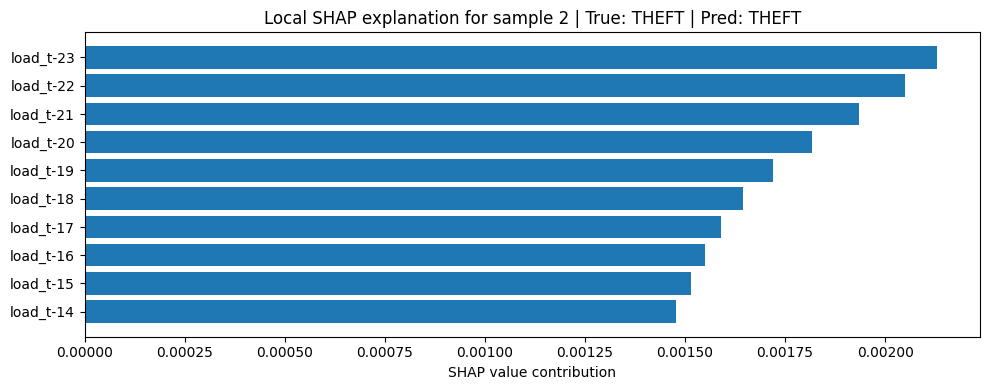

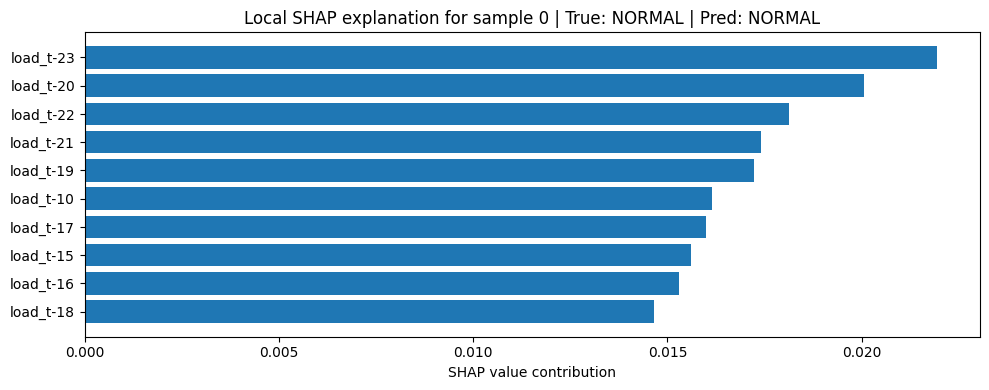

In [14]:
# Local SHAP explanations for representative correctly/incorrectly classified samples.
tp_candidates = np.where((subset_true == 1) & (subset_preds == 1))[0]
tn_candidates = np.where((subset_true == 0) & (subset_preds == 0))[0]
fp_candidates = np.where((subset_true == 0) & (subset_preds == 1))[0]
fn_candidates = np.where((subset_true == 1) & (subset_preds == 0))[0]

selected_examples = []
for label_name, candidates in [
    ('True Positive', tp_candidates),
    ('True Negative', tn_candidates),
    ('False Positive', fp_candidates),
    ('False Negative', fn_candidates),
]:
    if len(candidates) > 0:
        selected_examples.append((label_name, int(candidates[0])))

if not selected_examples:
    selected_examples = [('Sample', 0)]

for plot_id, (label_name, idx) in enumerate(selected_examples[:4]):
    sample_shap = shap_flat[idx]
    top_local = np.argsort(np.abs(sample_shap))[::-1][:10]

    plt.figure(figsize=(10, 4))
    plt.barh([feature_names[i] for i in top_local][::-1], sample_shap[top_local][::-1])
    plt.title(
        f'{label_name} explanation | '
        f'True: {"THEFT" if subset_true[idx] == 1 else "NORMAL"} | '
        f'Pred: {"THEFT" if subset_preds[idx] == 1 else "NORMAL"} | '
        f'Prob: {subset_probs[idx]:.3f} | Threshold: {best_threshold:.2f}'
    )
    plt.xlabel('SHAP value contribution')
    plt.tight_layout()
    plt.savefig(f'shap_local_bar_{plot_id}.png', dpi=150, bbox_inches='tight')
    plt.show()

## Adversarial Robustness Testing (FGSM)

This section measures how performance changes under bounded perturbations and visualizes robustness trends across epsilon levels.

In [17]:
# FGSM adversarial attack helper.
attack_criterion = nn.BCEWithLogitsLoss()
x_clip_min = float(X_train_t.min().item())
x_clip_max = float(X_train_t.max().item())

def fgsm_attack(model, x_batch, y_batch, epsilon=0.05):
    """Generate FGSM adversarial samples for a batch."""
    x_adv = x_batch.clone().detach().to(device)
    y_adv = y_batch.clone().detach().float().to(device)

    x_adv.requires_grad_(True)
    with torch.enable_grad():
        with torch.backends.cudnn.flags(enabled=False):
            logits = model(x_adv)
            loss = attack_criterion(logits, y_adv)
            gradient = torch.autograd.grad(loss, x_adv, retain_graph=False, create_graph=False)[0]

    perturbed = x_adv + epsilon * gradient.sign()
    perturbed = torch.clamp(perturbed, x_clip_min, x_clip_max)
    return perturbed.detach()

In [18]:
# Adversarial robustness test across epsilon values.
epsilon_values = [0.0, 0.01, 0.05, 0.1]
robustness_results = {}

y_true = y_test_t.numpy()

for eps in epsilon_values:
    model.eval()
    adv_preds = []
    adv_probs = []
    adv_logits = []

    for i in range(0, len(X_test_t), EVAL_BATCH_SIZE):
        batch_x = X_test_t[i:i + EVAL_BATCH_SIZE].to(device, non_blocking=PIN_MEMORY)
        batch_y = y_test_t[i:i + EVAL_BATCH_SIZE].to(device, non_blocking=PIN_MEMORY)

        if eps > 0:
            adv_x = fgsm_attack(model, batch_x, batch_y, epsilon=eps)
        else:
            adv_x = batch_x.detach()

        with torch.no_grad():
            adv_logits_batch = model(adv_x)
            adv_probs_batch = torch.sigmoid(adv_logits_batch)
            adv_preds_batch = (adv_probs_batch >= best_threshold).long()

        adv_logits.extend(adv_logits_batch.float().cpu().numpy())
        adv_probs.extend(adv_probs_batch.float().cpu().numpy())
        adv_preds.extend(adv_preds_batch.cpu().numpy())

    adv_preds = np.asarray(adv_preds)
    adv_probs = np.asarray(adv_probs)
    adv_logits = np.asarray(adv_logits)

    precision_a = precision_score(y_true, adv_preds, zero_division=0)
    recall_a = recall_score(y_true, adv_preds, zero_division=0)
    f1_a = f1_score(y_true, adv_preds, zero_division=0)
    balanced_a = balanced_accuracy_score(y_true, adv_preds)
    mcc_a = matthews_corrcoef(y_true, adv_preds)
    fn = int(np.logical_and(y_true == 1, adv_preds == 0).sum())
    tp = int(np.logical_and(y_true == 1, adv_preds == 1).sum())
    fnr_a = fn / max(fn + tp, 1)

    try:
        ap_a = average_precision_score(y_true, adv_probs)
    except ValueError:
        ap_a = 0.0

    robustness_results[eps] = {
        'precision': float(precision_a),
        'recall': float(recall_a),
        'f1': float(f1_a),
        'balanced_accuracy': float(balanced_a),
        'mcc': float(mcc_a),
        'fnr': float(fnr_a),
        'ap': float(ap_a),
    }

print('\nAdversarial Robustness Results:')
print(f'{"Epsilon":<10} {"Precision":<12} {"Recall":<12} {"F1-Score":<12} {"BAcc":<12} {"FNR":<10} {"AP":<12}')
print('-' * 84)
for eps, metrics in robustness_results.items():
    print(
        f'{eps:<10.2f} {metrics["precision"]:<12.4f} '
        f'{metrics["recall"]:<12.4f} {metrics["f1"]:<12.4f} '
        f'{metrics["balanced_accuracy"]:<12.4f} {metrics["fnr"]:<10.4f} {metrics["ap"]:<12.4f}'
    )


Adversarial Robustness Results:
Epsilon    Precision    Recall       F1-Score     BAcc         FNR        AP          
------------------------------------------------------------------------------------
0.00       0.9428       0.6108       0.7413       0.8034       0.3892     0.7443      
0.01       0.7139       0.5417       0.6160       0.7588       0.4583     0.6425      
0.05       0.2289       0.3150       0.2651       0.5985       0.6850     0.2780      
0.10       0.1656       0.3013       0.2137       0.5663       0.6987     0.1880      


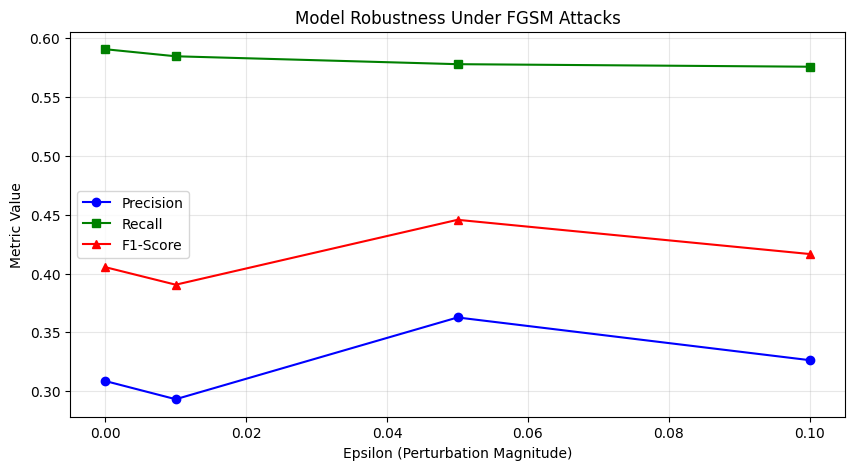

In [19]:
eps_list = list(robustness_results.keys())
precisions = [robustness_results[e]['precision'] for e in eps_list]
recalls = [robustness_results[e]['recall'] for e in eps_list]
f1s = [robustness_results[e]['f1'] for e in eps_list]

plt.figure(figsize=(10, 5))
plt.plot(eps_list, precisions, 'o-', label='Precision', color='blue')
plt.plot(eps_list, recalls, 's-', label='Recall', color='green')
plt.plot(eps_list, f1s, '^-', label='F1-Score', color='red')
plt.xlabel('Epsilon (Perturbation Magnitude)')
plt.ylabel('Metric Value')
plt.title('Model Robustness Under FGSM Attacks')
plt.legend()
plt.grid(alpha=0.3)
plt.savefig('adversarial_robustness.png', dpi=150, bbox_inches='tight')
plt.show()


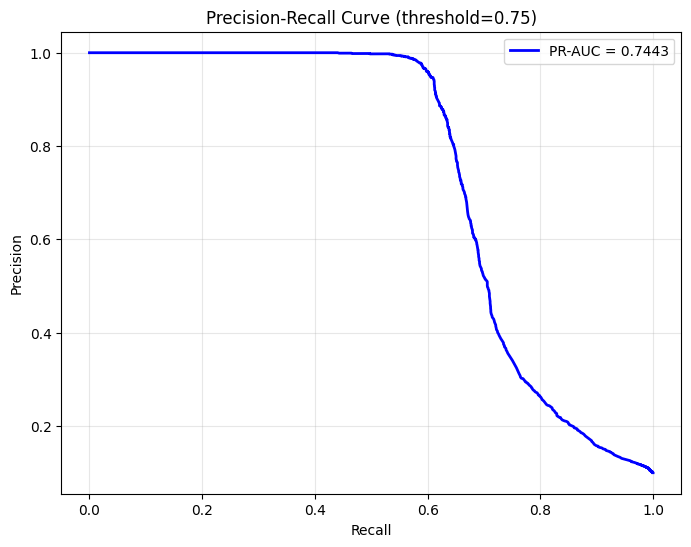

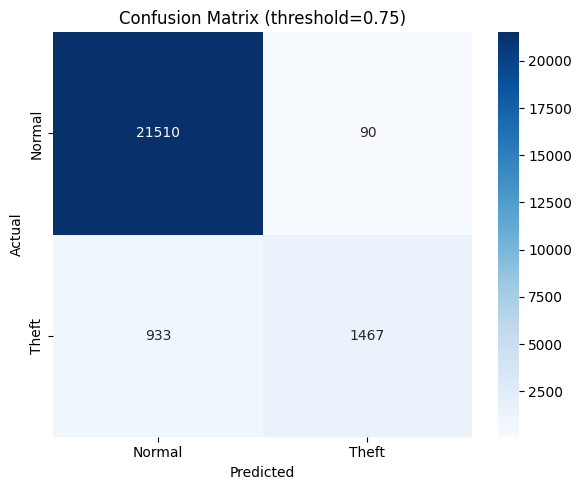

Confusion Matrix:
[[21510    90]
 [  933  1467]]


In [20]:
# Precision-Recall curve and confusion matrix.
precisions_curve, recalls_curve, _ = precision_recall_curve(y_true, all_probs)
pr_auc = auc(recalls_curve, precisions_curve)

plt.figure(figsize=(8, 6))
plt.plot(recalls_curve, precisions_curve, label=f'PR-AUC = {pr_auc:.4f}', color='blue', linewidth=2)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title(f'Precision-Recall Curve (threshold={best_threshold:.2f})')
plt.legend()
plt.grid(alpha=0.3)
plt.savefig('pr_curve.png', dpi=150, bbox_inches='tight')
plt.show()

cm = confusion_matrix(y_true, all_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Normal', 'Theft'],
    yticklabels=['Normal', 'Theft']
    )
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix (threshold={best_threshold:.2f})')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Confusion Matrix:\n{cm}')

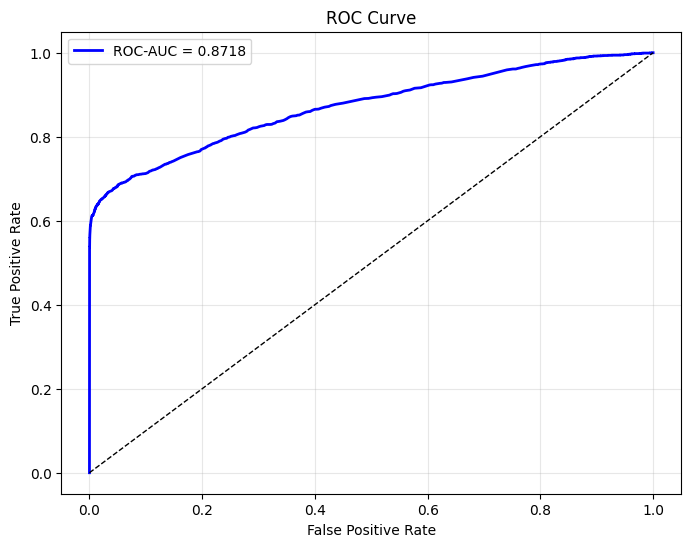

In [21]:
# ROC Curve.
fpr, tpr, _ = roc_curve(y_true, all_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC-AUC = {roc_auc:.4f}', color='blue', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', linewidth=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid(alpha=0.3)
plt.savefig('roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()

In [22]:
print('=' * 60)
print('FINAL RESULTS SUMMARY')
print('=' * 60)

print('\n1. Validation-Selected Decision Rule:')
print(f'   Best threshold: {best_threshold:.2f}')
print(f'   Best validation F1: {best_threshold_metrics.get("f1", float("nan")):.4f}')
print(f'   Best validation precision: {best_threshold_metrics.get("precision", float("nan")):.4f}')
print(f'   Best validation recall: {best_threshold_metrics.get("recall", float("nan")):.4f}')

print('\n2. Test Performance:')
print(f'   Precision: {test_metrics["precision"]:.4f}')
print(f'   Recall:    {test_metrics["recall"]:.4f}')
print(f'   F1-Score:  {test_metrics["f1"]:.4f}')
print(f'   Balanced Accuracy: {test_metrics["balanced_accuracy"]:.4f}')
print(f'   MCC:      {test_metrics["mcc"]:.4f}')
print(f'   PR-AUC:   {test_metrics["pr_auc"]:.4f}')
print(f'   ROC-AUC:  {test_metrics["roc_auc"]:.4f}')

print('\n3. Robustness Under FGSM:')
for eps in [0.0, 0.01, 0.05, 0.10]:
    metrics = robustness_results[eps]
    drop = robustness_results[0.0]['f1'] - metrics['f1']
    print(
        f'   Epsilon={eps:.2f}: F1={metrics["f1"]:.4f}, '
        f'Precision={metrics["precision"]:.4f}, Recall={metrics["recall"]:.4f}, '
        f'F1-Drop={drop:.4f}'
    )

print('\n4. Explainability Outputs:')
print('   SHAP summary: shap_summary.png')
print('   SHAP grouped importance: shap_group_importance.png')
print('   Local SHAP plots: shap_local_bar_*.png')
print('=' * 60)

FINAL RESULTS SUMMARY

1. Validation-Selected Decision Rule:
   Best threshold: 0.75
   Best validation F1: 0.7710
   Best validation precision: 0.9545
   Best validation recall: 0.6467

2. Test Performance:
   Precision: 0.9422
   Recall:    0.6112
   F1-Score:  0.7415
   Balanced Accuracy: 0.8035
   MCC:      0.7394
   PR-AUC:   0.7443
   ROC-AUC:  0.8718

3. Robustness Under FGSM:
   Epsilon=0.00: F1=0.7413, Precision=0.9428, Recall=0.6108, F1-Drop=0.0000
   Epsilon=0.01: F1=0.6160, Precision=0.7139, Recall=0.5417, F1-Drop=0.1254
   Epsilon=0.05: F1=0.2651, Precision=0.2289, Recall=0.3150, F1-Drop=0.4762
   Epsilon=0.10: F1=0.2137, Precision=0.1656, Recall=0.3013, F1-Drop=0.5276

4. Explainability Outputs:
   SHAP summary: shap_summary.png
   SHAP grouped importance: shap_group_importance.png
   Local SHAP plots: shap_local_bar_*.png


In [23]:
import json

def jsonable(value):
    if isinstance(value, (np.floating, np.integer)):
        return value.item()
    return value

# Export metrics to JSON for report population.
baseline = robustness_results.get(0.0, {})

results = {
    'best_threshold': float(best_threshold),
    'validation_metrics': {
        key: jsonable(value)
        for key, value in best_threshold_metrics.items()
    },
    'test_metrics': {
        key: jsonable(value)
        for key, value in test_metrics.items()
    },
    'robustness_under_attack': {
        str(epsilon): {metric: jsonable(value) for metric, value in metrics.items()}
        for epsilon, metrics in robustness_results.items()
    },
    'feature_group_importance': {name: float(score) for name, score in feature_group_importance.items()},
    'confusion_matrix': cm.tolist(),
    'pr_auc': float(pr_auc),
    'roc_auc': float(roc_auc),
    'brier_score': float(test_metrics['brier']),
    'log_loss': float(test_metrics['logloss']),
}

with open('results.json', 'w') as f:
    json.dump(results, f, indent=2)

print(json.dumps(results, indent=2))
print('\nResults exported to results.json')

{
  "best_threshold": 0.7499999999999999,
  "validation_metrics": {
    "threshold": 0.7499999999999999,
    "precision": 0.9544895448954489,
    "recall": 0.6466666666666666,
    "f1": 0.7709885742672627,
    "balanced_accuracy": 0.8216205289633676,
    "mcc": 0.7678473008273503
  },
  "test_metrics": {
    "precision": 0.9421965317919075,
    "recall": 0.61125,
    "f1": 0.7414708112206216,
    "balanced_accuracy": 0.8035416666666666,
    "mcc": 0.7394282612625832,
    "cohen_kappa": 0.7193877551020409,
    "test_loss": 0.04110144074757894,
    "threshold": 0.7499999999999999,
    "brier": 0.24755802750587463,
    "logloss": 0.678635684329065,
    "pr_auc": 0.7443046119168805,
    "roc_auc": 0.8718097993827161
  },
  "robustness_under_attack": {
    "0.0": {
      "precision": 0.9427652733118971,
      "recall": 0.6108333333333333,
      "f1": 0.7413400758533502,
      "balanced_accuracy": 0.8033564814814815,
      "mcc": 0.7394192776325024,
      "fnr": 0.38916666666666666,
      "a